<a href="https://www.kaggle.com/code/isithadinujaya/pinns-for-quantum-tomography?scriptVersionId=305217180" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import torch
import torch.nn as mm
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from itertools import product

In [6]:
#device = torch.device("cuda" if torch.cuda)

In [7]:
# define the pauli matroices

I = torch.eye(2, dtype=torch.complex128, device = device)
X = torch.tensor([[0,1],[1,0]],dtype=torch.complex128, device = device)
Y = torch.tensor([[0,-1j],[1j,0]],dtype=torch.complex128, device = device)
Z = torch.tensor([[1,0],[0,-1]],dtype=torch.complex128, device = device)

paulis_1q = [I,X,Y,Z]


In [8]:
def generate_pauli_strings(n_qubits):
    return list(product(range(4), repeat = n_qubits))

def pauli_strings_to_matrix(ps):
    mat  = torch.tensor([1], dtype = torch.complex128, device = device).reshape(1,1)
    for p in ps:
        mat = torch.kron(mat, paulis_1q[p]) #kronker product
    return mat

In [9]:
def build_rho_from_coeffs(coeffs, n_qubits, pauloi_strings_nonid):
    


SyntaxError: incomplete input (3889978481.py, line 2)

In [ ]:
# ======================================================================
# Complete Implementation of Quantum Noise Tomography with PINNs
# ======================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from itertools import product

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------------------------------------------------
# Pauli matrices
# ----------------------------------------------------------------------
I = torch.eye(2, dtype=torch.complex128, device=device)
X = torch.tensor([[0., 1.], [1., 0.]], dtype=torch.complex128, device=device)
Y = torch.tensor([[0., -1j], [1j, 0.]], dtype=torch.complex128, device=device)
Z = torch.tensor([[1., 0.], [0., -1.]], dtype=torch.complex128, device=device)
paulis_1q = [I, X, Y, Z]

def generate_pauli_strings(n_qubits):
    return list(product(range(4), repeat=n_qubits))

def pauli_string_to_matrix(ps):
    mat = torch.tensor([1.], dtype=torch.complex128, device=device).reshape(1,1)
    for p in ps:
        mat = torch.kron(mat, paulis_1q[p])
    return mat

# ----------------------------------------------------------------------
# Build density matrix from Pauli coefficients
# ----------------------------------------------------------------------
def build_rho_from_coeffs(coeffs, n_qubits, pauli_strings_nonid):
    """
    coeffs: (batch, n_paulis) real tensor
    returns: (batch, 2^n, 2^n) complex
    """
    dim = 2**n_qubits
    batch = coeffs.shape[0]
    rho = torch.eye(dim, dtype=torch.complex128, device=device).unsqueeze(0) / (2**n_qubits)
    rho = rho.expand(batch, -1, -1).clone()
    for i, ps in enumerate(pauli_strings_nonid):
        mat = pauli_string_to_matrix(ps)
        rho = rho + coeffs[:, i].view(-1,1,1) * mat / (2**n_qubits)
    return rho

# ----------------------------------------------------------------------
# Lindblad right-hand side
# ----------------------------------------------------------------------
def lindblad_rhs(rho, H, jump_ops, rates):
    """
    rho: (batch, dim, dim) complex
    rates: list of length n_rates, each element is scalar or (batch,) tensor
    """
    comm = -1j * (H @ rho - rho @ H)
    dissipator = torch.zeros_like(rho)
    for L, gamma in zip(jump_ops, rates):
        if not isinstance(gamma, torch.Tensor):
            gamma = torch.tensor(gamma, dtype=torch.complex128, device=device)
        if gamma.dim() == 0:
            gamma = gamma.view(1)
        # Ensure gamma is broadcastable to batch
        gamma = gamma.view(-1,1,1)
        LrhoL = L @ rho @ L.conj().T
        LdagL = L.conj().T @ L
        anticom = LdagL @ rho + rho @ LdagL
        dissipator = dissipator + gamma * (LrhoL - 0.5 * anticom)
    return comm + dissipator

# ----------------------------------------------------------------------
# Residual block
# ----------------------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
    def forward(self, x):
        return x + self.fc2(self.act(self.fc1(x)))

# ----------------------------------------------------------------------
# PINN for Lindblad tomography
# ----------------------------------------------------------------------
class LindbladPINN(nn.Module):
    def __init__(self, n_qubits, hidden_dim=64, n_blocks=2,
                 use_fourier=False, fourier_dim=10,
                 time_varying_rates=False, n_rates=0):
        super().__init__()
        self.n_qubits = n_qubits
        self.dim = 2**n_qubits
        self.n_paulis = 4**n_qubits - 1
        self.time_varying_rates = time_varying_rates
        self.n_rates = n_rates

        # Fourier features
        self.use_fourier = use_fourier
        if use_fourier:
            self.B = nn.Parameter(torch.randn(fourier_dim, 1) * 10.0, requires_grad=False)
            input_dim = 2 * fourier_dim
        else:
            input_dim = 1

        # Build network
        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_blocks):
            layers.append(ResidualBlock(hidden_dim))
        self.backbone = nn.Sequential(*layers)

        # Output heads
        self.rho_head = nn.Linear(hidden_dim, self.n_paulis)
        if time_varying_rates:
            self.rates_head = nn.Linear(hidden_dim, n_rates)
        else:
            self.rates = nn.Parameter(torch.randn(n_rates) * 0.1)

        # Precompute non-identity Pauli strings
        all_ps = generate_pauli_strings(n_qubits)
        self.pauli_strings_nonid = [ps for ps in all_ps if not all(p==0 for p in ps)]

    def forward(self, t):
        if t.dim() == 0:
            t = t.unsqueeze(0)
        # Fourier encoding
        if self.use_fourier:
            t_flat = t.view(-1, 1).to(torch.float32)
            proj = 2 * np.pi * t_flat @ self.B.T  # (batch, fourier_dim)
            x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        else:
            x = t.view(-1, 1).to(torch.float32)

        h = self.backbone(x)
        coeffs = self.rho_head(h)  # (batch, n_paulis)

        # Build density matrices
        rho = build_rho_from_coeffs(coeffs, self.n_qubits, self.pauli_strings_nonid)

        if self.time_varying_rates:
            rates = self.rates_head(h)
            rates = nn.functional.softplus(rates)  # ensure positivity
            return rho, rates
        else:
            # constant rates (broadcast later)
            return rho, self.rates

# ----------------------------------------------------------------------
# Training function for a given case
# ----------------------------------------------------------------------
def run_case(case=1):
    """
    case: 1 (single qubit, time-varying), 2 (two-qubit constant), 3 (two-qubit entangled)
    """
    np.random.seed(42)
    torch.manual_seed(42)

    # ==================== Case 1: Single qubit, time-varying rates ====================
    if case == 1:
        n_qubits = 1
        dim = 2
        H = 0.5 * X  # example Hamiltonian
        # Jump operators: amplitude damping and dephasing
        L_ad = torch.tensor([[0., 1.], [0., 0.]], dtype=torch.complex128, device=device)  # sigma-
        L_pd = Z
        jump_ops = [L_ad, L_pd]
        # True time-varying rates
        def true_rates(t):
            gamma_ad = 0.2 + 0.1 * np.sin(2 * np.pi * t)  # sinusoidal
            gamma_pd = 0.3 * np.exp(-0.5 * t)            # exponential decay
            return [gamma_ad, gamma_pd]
        rho0 = torch.tensor([[1., 0.], [0., 0.]], dtype=torch.complex128, device=device)  # |0>

        # PINN with time-varying rates
        pinn = LindbladPINN(n_qubits, hidden_dim=64, n_blocks=2,
                            time_varying_rates=True, n_rates=2).to(device)

        # Training data parameters
        t_span = [0.0, 5.0]
        n_data = 30
        noise_std = 0.0  # no noise for this case
        n_colloc = 200
        n_epochs = 10000
        lr = 1e-3

    # ==================== Case 2: Two qubits, constant local noise ====================
    elif case == 2:
        n_qubits = 2
        dim = 4
        # Hamiltonian (e.g., something simple)
        H = torch.kron(X, I) + torch.kron(I, X)  # example
        # Local noise channels: AD and PD on each qubit
        L_ad1 = torch.kron(torch.tensor([[0.,1.],[0.,0.]], dtype=torch.complex128, device=device), I)
        L_pd1 = torch.kron(Z, I)
        L_ad2 = torch.kron(I, torch.tensor([[0.,1.],[0.,0.]], dtype=torch.complex128, device=device))
        L_pd2 = torch.kron(I, Z)
        jump_ops = [L_ad1, L_pd1, L_ad2, L_pd2]
        # True constant rates
        true_rates_const = [0.25, 0.15, 0.10, 0.30]
        def true_rates(t):
            return true_rates_const
        rho0 = torch.zeros(dim, dim, dtype=torch.complex128, device=device)
        rho0[0,0] = 1.0  # |00>

        # PINN with constant rates
        pinn = LindbladPINN(n_qubits, hidden_dim=64, n_blocks=2,
                            time_varying_rates=False, n_rates=4).to(device)

        t_span = [0.0, 5.0]
        n_data = 25
        noise_std = 0.05  # example noise level
        n_colloc = 200
        n_epochs = 10000
        lr = 1e-3

    # ==================== Case 3: Two qubits, entangled, high-frequency ====================
    elif case == 3:
        n_qubits = 2
        dim = 4
        # Hamiltonian that generates entanglement (e.g., Ising + transverse field)
        H = torch.kron(X, X) + 0.5 * (torch.kron(Z, I) + torch.kron(I, Z))
        H = H.to(torch.complex128)
        # Same noise channels as case 2
        L_ad1 = torch.kron(torch.tensor([[0.,1.],[0.,0.]], dtype=torch.complex128, device=device), I)
        L_pd1 = torch.kron(Z, I)
        L_ad2 = torch.kron(I, torch.tensor([[0.,1.],[0.,0.]], dtype=torch.complex128, device=device))
        L_pd2 = torch.kron(I, Z)
        jump_ops = [L_ad1, L_pd1, L_ad2, L_pd2]
        true_rates_const = [0.25, 0.15, 0.10, 0.30]  # same as case 2 for comparison
        def true_rates(t):
            return true_rates_const
        rho0 = torch.zeros(dim, dim, dtype=torch.complex128, device=device)
        rho0[0,0] = 1.0

        # PINN with Fourier features and constant rates
        pinn = LindbladPINN(n_qubits, hidden_dim=64, n_blocks=3,
                            use_fourier=True, fourier_dim=10,
                            time_varying_rates=False, n_rates=4).to(device)

        t_span = [0.0, 5.0]
        n_data = 30
        noise_std = 0.0  # no noise for this case in paper (they show clean data)
        n_colloc = 200
        n_epochs = 10000
        lr = 1e-3  # AdamW used in paper, we'll just use Adam for simplicity

    # ==================== Common data generation ====================
    # Generate true dynamics for reference and data
    def odefunc(t, rho_vec):
        rho = rho_vec.reshape(dim, dim).astype(np.complex128)
        rho_t = torch.tensor(rho, dtype=torch.complex128, device=device).unsqueeze(0)
        rates = true_rates(t)
        drho = lindblad_rhs(rho_t, H, jump_ops, rates)
        return drho.squeeze(0).cpu().detach().numpy().reshape(-1).astype(np.complex128)

    t_eval = np.linspace(t_span[0], t_span[1], 1000)
    rho0_vec = rho0.cpu().numpy().reshape(-1)
    sol = solve_ivp(odefunc, t_span, rho0_vec, t_eval=t_eval, method='DOP853', rtol=1e-8, atol=1e-8)
    true_rho = sol.y.T.reshape(-1, dim, dim)  # (1000, dim, dim)

    # Select sparse data points
    t_data = np.random.uniform(t_span[0], t_span[1], n_data)
    t_data = np.sort(t_data)

    # Observables: for 1 qubit: X,Y,Z; for 2 qubits: X1,Z1,X2,Z2
    if n_qubits == 1:
        obs_matrices = [X, Y, Z]
    else:
        obs_matrices = [
            torch.kron(X, I),  # X1
            torch.kron(Z, I),  # Z1
            torch.kron(I, X),  # X2
            torch.kron(I, Z),  # Z2
        ]
    obs_matrices = [m.to(device) for m in obs_matrices]

    # Generate measurements: for each t in t_data, pick a random observable
    data_t = []
    data_idx = []
    data_val = []
    for t_val in t_data:
        obs_idx = np.random.randint(len(obs_matrices))
        idx = np.argmin(np.abs(t_eval - t_val))
        rho_true = torch.tensor(true_rho[idx], dtype=torch.complex128, device=device)
        val = torch.real(torch.trace(rho_true @ obs_matrices[obs_idx])).item()
        if noise_std > 0:
            val += np.random.normal(0, noise_std)
        data_t.append(t_val)
        data_idx.append(obs_idx)
        data_val.append(val)

    data_t = torch.tensor(data_t, dtype=torch.float32, device=device)
    data_idx = torch.tensor(data_idx, dtype=torch.long, device=device)
    data_val = torch.tensor(data_val, dtype=torch.float32, device=device)

    # Collocation points
    t_colloc = torch.linspace(t_span[0], t_span[1], n_colloc, device=device, requires_grad=True)

    # ==================== Loss weights ====================
    w_data = 1.0
    w_phys = 10.0
    w_ic = 1.0
    w_pos = 1.0

    # ==================== Optimizer ====================
    optimizer = optim.Adam(pinn.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

    # ==================== Training loop ====================
    loss_history = []
    for epoch in range(n_epochs):
        pinn.train()
        optimizer.zero_grad()

        # Forward on collocation points
        if pinn.time_varying_rates:
            rho_c, rates_c = pinn(t_colloc)
        else:
            rho_c, rates_const = pinn(t_colloc)
            # rates_const is a parameter; expand to batch for physics loss
            rates_c = rates_const.unsqueeze(0).expand(n_colloc, -1)  # (n_colloc, n_rates)

        # ---- Physics loss ----
        # Compute dρ/dt using autograd
        # rho_c is complex, we need to get gradient with respect to t_colloc
        # We'll compute gradient of real and imaginary parts separately and combine
        drho_dt = torch.autograd.grad(rho_c, t_colloc,
                                      grad_outputs=torch.ones_like(rho_c),
                                      create_graph=True)[0]  # (n_colloc, dim, dim) complex

        # Compute RHS using current rates
        # For constant rates, we need to pass rates_c (each row is the same constants)
        # But rates_c is (n_colloc, n_rates). For lindblad_rhs we need list of (n_colloc,) tensors
        if pinn.time_varying_rates:
            rates_list = [rates_c[:, i] for i in range(pinn.n_rates)]
        else:
            rates_list = [rates_c[:, i] for i in range(pinn.n_rates)]
        rhs = lindblad_rhs(rho_c, H, jump_ops, rates_list)
        phys_loss = torch.mean(torch.abs(drho_dt - rhs)**2)

        # ---- Data loss ----
        # Forward at data times
        if pinn.time_varying_rates:
            rho_d, _ = pinn(data_t)
        else:
            rho_d, _ = pinn(data_t)
        # Compute predicted observables
        pred_vals = []
        for i in range(len(data_t)):
            O = obs_matrices[data_idx[i]]
            pred = torch.real(torch.trace(rho_d[i] @ O))
            pred_vals.append(pred)
        pred_vals = torch.stack(pred_vals)
        data_loss = torch.mean((pred_vals - data_val)**2)

        # ---- Initial condition loss ----
        if pinn.time_varying_rates:
            rho0_pred, _ = pinn(torch.tensor([0.0], device=device))
        else:
            rho0_pred, _ = pinn(torch.tensor([0.0], device=device))
        ic_loss = torch.mean(torch.abs(rho0_pred.squeeze(0) - rho0)**2)

        # ---- Positivity penalty ----
        # Compute eigenvalues of each rho in batch and penalize negative ones
        # Use torch.linalg.eigvalsh (only works for real symmetric, but rho is Hermitian)
        # We'll convert to complex and use eigh
        def positivity_penalty(rho_batch):
            # rho_batch: (batch, dim, dim) complex
            batch = rho_batch.shape[0]
            penalty = 0.0
            for i in range(batch):
                eigvals = torch.linalg.eigvalsh(rho_batch[i])  # real eigenvalues
                penalty = penalty + torch.sum(torch.relu(-eigvals))
            return penalty / batch

        pos_loss = positivity_penalty(rho_c) + positivity_penalty(rho_d) + positivity_penalty(rho0_pred)

        # Total loss
        total_loss = w_data * data_loss + w_phys * phys_loss + w_ic * ic_loss + w_pos * pos_loss

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        loss_history.append(total_loss.item())

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {total_loss.item():.3e} | data: {data_loss.item():.3e} | phys: {phys_loss.item():.3e} | ic: {ic_loss.item():.3e} | pos: {pos_loss.item():.3e}")

    # ==================== Final evaluation ====================
    # Plot results
    t_plot = torch.linspace(t_span[0], t_span[1], 200, device=device)
    with torch.no_grad():
        if pinn.time_varying_rates:
            rho_plot, rates_plot = pinn(t_plot)
        else:
            rho_plot, rates_const = pinn(t_plot)
            rates_plot = rates_const.unsqueeze(0).expand(200, -1)

    # For single qubit, plot expectation values
    if n_qubits == 1:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        for i, O in enumerate([X, Y, Z]):
            pred_exp = [torch.real(torch.trace(rho_plot[j] @ O)).item() for j in range(200)]
            plt.plot(t_plot.cpu(), pred_exp, label=f'PINN {["X","Y","Z"][i]}')
        # Plot true from simulation
        true_exp = []
        for j in range(200):
            idx = np.argmin(np.abs(t_eval - t_plot[j].cpu()))
            rho_true = true_rho[idx]
            true_exp.append([np.real(np.trace(rho_true @ O.cpu().numpy())) for O in [X,Y,Z]])
        true_exp = np.array(true_exp)
        plt.plot(t_eval, true_exp[:,0], '--', label='True X', color='C0')
        plt.plot(t_eval, true_exp[:,1], '--', label='True Y', color='C1')
        plt.plot(t_eval, true_exp[:,2], '--', label='True Z', color='C2')
        # Plot data points
        for i, idx in enumerate(data_idx):
            plt.scatter(data_t[i].cpu(), data_val[i].cpu(), marker='x', color='k')
        plt.xlabel('t')
        plt.ylabel('Expectation')
        plt.legend()
        plt.title('Dynamics')

        plt.subplot(1,2,2)
        # Plot learned rates
        rates_ad = rates_plot[:,0].cpu().numpy()
        rates_pd = rates_plot[:,1].cpu().numpy()
        t_np = t_plot.cpu().numpy()
        plt.plot(t_np, rates_ad, label='PINN γ_AD')
        plt.plot(t_np, rates_pd, label='PINN γ_PD')
        # True rates
        true_ad = [true_rates(t)[0] for t in t_np]
        true_pd = [true_rates(t)[1] for t in t_np]
        plt.plot(t_np, true_ad, '--', label='True γ_AD')
        plt.plot(t_np, true_pd, '--', label='True γ_PD')
        plt.xlabel('t')
        plt.ylabel('Rate')
        plt.legend()
        plt.title('Learned time-varying rates')
        plt.tight_layout()
        plt.show()

    else:  # two qubits
        plt.figure(figsize=(12,8))
        obs_names = ['X1','Z1','X2','Z2']
        for k in range(4):
            plt.subplot(2,2,k+1)
            # PINN prediction
            pred_exp = [torch.real(torch.trace(rho_plot[j] @ obs_matrices[k])).item() for j in range(200)]
            plt.plot(t_plot.cpu(), pred_exp, label='PINN')
            # True
            true_exp = []
            for j in range(200):
                idx = np.argmin(np.abs(t_eval - t_plot[j].cpu()))
                rho_true = true_rho[idx]
                true_exp.append(np.real(np.trace(rho_true @ obs_matrices[k].cpu().numpy())))
            plt.plot(t_eval, true_exp, '--', label='True')
            # Data points for this observable
            mask = data_idx.cpu().numpy() == k
            plt.scatter(data_t.cpu().numpy()[mask], data_val.cpu().numpy()[mask], marker='x', color='k')
            plt.xlabel('t')
            plt.ylabel(f'⟨{obs_names[k]}⟩')
            plt.legend()
        plt.suptitle('Two-qubit dynamics')
        plt.tight_layout()
        plt.show()

        # Print learned rates
        if pinn.time_varying_rates:
            print("Time-varying rates not expected in this case.")
        else:
            learned = rates_const.detach().cpu().numpy()
            true = true_rates_const
            print("Learned rates:", learned)
            print("True rates:   ", true)

    return pinn, loss_history

# ======================================================================
# Run the desired case
# ======================================================================
if __name__ == "__main__":
    # Choose case: 1, 2, or 3
    pinn, loss = run_case(case=2)  # change to 1 or 3 as needed

Using device: cpu

Case 1 — Adam phase: 100000 epochs
Epoch      0 | total: 1.428e+01 | data: 5.937e-01 | phys: 1.332e+00 | ic: 1.970e-01 | pos: 1.659e-01
Epoch  10000 | total: 1.112e-04 | data: 8.543e-05 | phys: 2.578e-06 | ic: 1.672e-09 | pos: 0.000e+00
Epoch  20000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  30000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  40000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  50000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  60000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  70000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  80000 | total: 1.109e-04 | data: 8.528e-05 | phys: 2.559e-06 | ic: 1.873e-09 | pos: 0.000e+00
Epoch  90000 | total: 1.109e-04 | dat

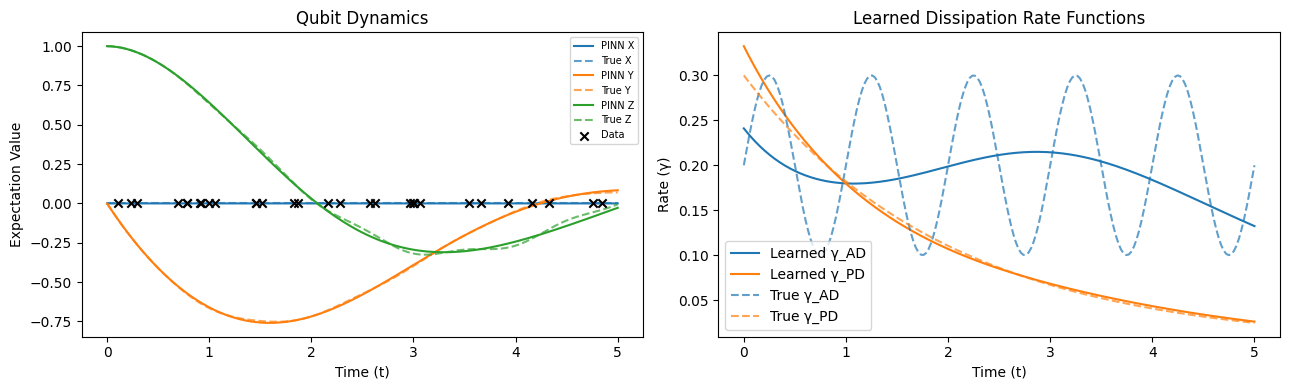

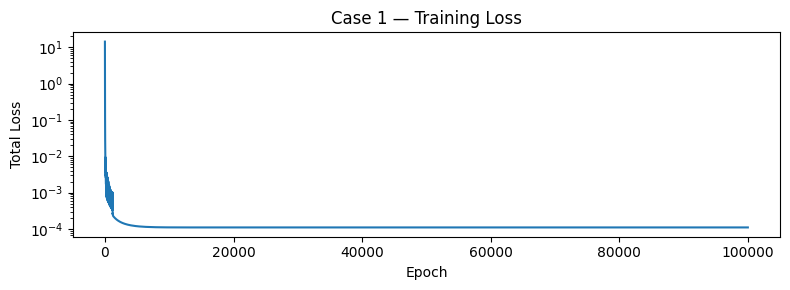

In [3]:
# ======================================================================
# Complete Implementation of Quantum Noise Tomography with PINNs
# Corrected to match paper: arXiv:2509.11911
# ======================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from itertools import product

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------------------------------------------------
# Pauli matrices
# ----------------------------------------------------------------------
I = torch.eye(2, dtype=torch.complex128, device=device)
X = torch.tensor([[0., 1.], [1., 0.]], dtype=torch.complex128, device=device)
Y = torch.tensor([[0., -1j], [1j, 0.]], dtype=torch.complex128, device=device)
Z = torch.tensor([[1., 0.], [0., -1.]], dtype=torch.complex128, device=device)
paulis_1q = [I, X, Y, Z]


def generate_pauli_strings(n_qubits):
    return list(product(range(4), repeat=n_qubits))


def pauli_string_to_matrix(ps):
    mat = torch.tensor([1.], dtype=torch.complex128, device=device).reshape(1, 1)
    for p in ps:
        mat = torch.kron(mat, paulis_1q[p])
    return mat


# ----------------------------------------------------------------------
# Build density matrix from Pauli coefficients
# ----------------------------------------------------------------------
def build_rho_from_coeffs(coeffs, n_qubits, pauli_strings_nonid):
    dim = 2 ** n_qubits
    batch = coeffs.shape[0]
    rho = torch.eye(dim, dtype=torch.complex128, device=device).unsqueeze(0) / (2 ** n_qubits)
    rho = rho.expand(batch, -1, -1).clone()
    for i, ps in enumerate(pauli_strings_nonid):
        mat = pauli_string_to_matrix(ps)
        rho = rho + coeffs[:, i].to(torch.complex128).view(-1, 1, 1) * mat / (2 ** n_qubits)
    return rho


# ----------------------------------------------------------------------
# Lindblad RHS
# ----------------------------------------------------------------------
def lindblad_rhs(rho, H, jump_ops, rates):
    comm = -1j * (H @ rho - rho @ H)
    dissipator = torch.zeros_like(rho)
    for L, gamma in zip(jump_ops, rates):
        if not isinstance(gamma, torch.Tensor):
            gamma = torch.tensor(gamma, dtype=torch.complex128, device=device)
        gamma = gamma.to(torch.complex128)
        if gamma.dim() == 0:
            gamma = gamma.view(1)
        gamma = gamma.view(-1, 1, 1)
        LrhoL = L @ rho @ L.conj().T
        LdagL = L.conj().T @ L
        anticom = LdagL @ rho + rho @ LdagL
        dissipator = dissipator + gamma * (LrhoL - 0.5 * anticom)
    return comm + dissipator


# ----------------------------------------------------------------------
# Residual block
# ----------------------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.SiLU()

    def forward(self, x):
        return x + self.fc2(self.act(self.fc1(x)))


# ----------------------------------------------------------------------
# PINN for Lindblad tomography
# ----------------------------------------------------------------------
class LindbladPINN(nn.Module):
    def __init__(self, n_qubits, hidden_dim=64, n_blocks=2,
                 use_fourier=False, fourier_dim=10,
                 time_varying_rates=False, n_rates=0):
        super().__init__()
        self.n_qubits = n_qubits
        self.dim = 2 ** n_qubits
        self.n_paulis = 4 ** n_qubits - 1
        self.time_varying_rates = time_varying_rates
        self.n_rates = n_rates

        self.use_fourier = use_fourier
        if use_fourier:
            # Fixed random Fourier features (not learned), as in Tancik et al.
            B_init = torch.randn(fourier_dim, 1) * 10.0
            self.register_buffer('B', B_init)
            input_dim = 2 * fourier_dim
        else:
            input_dim = 1

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_blocks):
            layers.append(ResidualBlock(hidden_dim))
        self.backbone = nn.Sequential(*layers)

        self.rho_head = nn.Linear(hidden_dim, self.n_paulis)
        if time_varying_rates:
            self.rates_head = nn.Linear(hidden_dim, n_rates)
        else:
            self.log_rates = nn.Parameter(torch.full((n_rates,), -2.0))  # init near small positive

        all_ps = generate_pauli_strings(n_qubits)
        self.pauli_strings_nonid = [ps for ps in all_ps if not all(p == 0 for p in ps)]

    def get_constant_rates(self):
        # Softplus ensures positivity for constant rates
        return nn.functional.softplus(self.log_rates)

    def forward(self, t):
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if self.use_fourier:
            t_flat = t.view(-1, 1).to(torch.float32)
            proj = 2 * np.pi * t_flat @ self.B.T.float()
            x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        else:
            x = t.view(-1, 1).to(torch.float32)

        h = self.backbone(x)
        coeffs = self.rho_head(h)
        rho = build_rho_from_coeffs(coeffs, self.n_qubits, self.pauli_strings_nonid)

        if self.time_varying_rates:
            rates = nn.functional.softplus(self.rates_head(h))  # (batch, n_rates)
            return rho, rates
        else:
            return rho, self.get_constant_rates()


# ----------------------------------------------------------------------
# Positivity penalty (Eq. 4 in paper)
# ----------------------------------------------------------------------
def positivity_penalty(rho_batch):
    batch = rho_batch.shape[0]
    penalty = torch.tensor(0.0, dtype=torch.float64, device=device)
    for i in range(batch):
        eigvals = torch.linalg.eigvalsh(rho_batch[i])
        penalty = penalty + torch.sum(torch.relu(-eigvals.real))
    return penalty / batch


# ----------------------------------------------------------------------
# Compute observable expectations
# ----------------------------------------------------------------------
def compute_expectations(rho_batch, obs_list):
    # rho_batch: (batch, dim, dim), obs_list: list of matrices
    # returns (batch, n_obs) real tensor
    results = []
    for O in obs_list:
        # trace(rho @ O) for each batch element
        val = torch.real(torch.einsum('bij,ji->b', rho_batch, O))
        results.append(val)
    return torch.stack(results, dim=1)


# ----------------------------------------------------------------------
# Main training function
# ----------------------------------------------------------------------
def run_case(case=1):
    np.random.seed(42)
    torch.manual_seed(42)

    # ==================== Case configs ====================
    if case == 1:
        n_qubits = 1
        dim = 2
        H = (0.5 * X).to(torch.complex128)

        L_ad = torch.tensor([[0., 1.], [0., 0.]], dtype=torch.complex128, device=device)
        L_pd = Z.clone()
        jump_ops = [L_ad, L_pd]

        def true_rates(t):
            return [0.2 + 0.1 * np.sin(2 * np.pi * t),
                    0.3 * np.exp(-0.5 * t)]

        rho0 = torch.tensor([[1., 0.], [0., 0.]], dtype=torch.complex128, device=device)

        pinn = LindbladPINN(n_qubits, hidden_dim=64, n_blocks=2,
                            time_varying_rates=True, n_rates=2).to(device)

        t_span = [0.0, 5.0]
        n_data = 30
        noise_std = 0.0
        n_colloc = 200
        n_epochs = 100_000
        lr = 1e-3
        use_lbfgs = False

    elif case == 2:
        n_qubits = 2
        dim = 4
        H = (torch.kron(X, I) + torch.kron(I, X)).to(torch.complex128)

        L_ad1 = torch.kron(torch.tensor([[0., 1.], [0., 0.]], dtype=torch.complex128, device=device), I)
        L_pd1 = torch.kron(Z, I)
        L_ad2 = torch.kron(I, torch.tensor([[0., 1.], [0., 0.]], dtype=torch.complex128, device=device))
        L_pd2 = torch.kron(I, Z)
        jump_ops = [L_ad1, L_pd1, L_ad2, L_pd2]

        true_rates_const = [0.25, 0.15, 0.10, 0.30]
        def true_rates(t): return true_rates_const

        rho0 = torch.zeros(dim, dim, dtype=torch.complex128, device=device)
        rho0[0, 0] = 1.0

        pinn = LindbladPINN(n_qubits, hidden_dim=64, n_blocks=2,
                            time_varying_rates=False, n_rates=4).to(device)

        t_span = [0.0, 5.0]
        n_data = 25
        noise_std = 0.05
        n_colloc = 200
        n_epochs = 100_000
        lr = 1e-3
        use_lbfgs = False

    elif case == 3:
        n_qubits = 2
        dim = 4
        H = (torch.kron(X, X) + 0.5 * (torch.kron(Z, I) + torch.kron(I, Z))).to(torch.complex128)

        L_ad1 = torch.kron(torch.tensor([[0., 1.], [0., 0.]], dtype=torch.complex128, device=device), I)
        L_pd1 = torch.kron(Z, I)
        L_ad2 = torch.kron(I, torch.tensor([[0., 1.], [0., 0.]], dtype=torch.complex128, device=device))
        L_pd2 = torch.kron(I, Z)
        jump_ops = [L_ad1, L_pd1, L_ad2, L_pd2]

        true_rates_const = [0.25, 0.15, 0.10, 0.30]
        def true_rates(t): return true_rates_const

        rho0 = torch.zeros(dim, dim, dtype=torch.complex128, device=device)
        rho0[0, 0] = 1.0

        # Fourier features + 3 residual blocks as per Appendix A
        pinn = LindbladPINN(n_qubits, hidden_dim=64, n_blocks=3,
                            use_fourier=True, fourier_dim=10,
                            time_varying_rates=False, n_rates=4).to(device)

        t_span = [0.0, 5.0]
        n_data = 30
        noise_std = 0.0
        n_colloc = 200
        n_epochs = 100_000
        lr = 1e-3
        use_lbfgs = True  # AdamW + L-BFGS refinement as per paper

    else:
        raise ValueError(f"Unknown case: {case}")

    # ==================== Generate true dynamics via ODE ====================
    def odefunc(t, rho_vec):
        rho = rho_vec.reshape(dim, dim).astype(np.complex128)
        rho_t = torch.tensor(rho, dtype=torch.complex128, device=device).unsqueeze(0)
        rates = true_rates(t)
        drho = lindblad_rhs(rho_t, H, jump_ops, rates)
        return drho.squeeze(0).cpu().detach().numpy().reshape(-1)

    t_eval = np.linspace(t_span[0], t_span[1], 1000)
    sol = solve_ivp(odefunc, t_span, rho0.cpu().numpy().reshape(-1),
                    t_eval=t_eval, method='DOP853', rtol=1e-8, atol=1e-8)
    true_rho = sol.y.T.reshape(-1, dim, dim)

    # ==================== Observables ====================
    if n_qubits == 1:
        obs_matrices = [X.clone(), Y.clone(), Z.clone()]
        obs_names = ['X', 'Y', 'Z']
    else:
        obs_matrices = [
            torch.kron(X, I), torch.kron(Z, I),
            torch.kron(I, X), torch.kron(I, Z),
        ]
        obs_names = ['X1', 'Z1', 'X2', 'Z2']
    obs_matrices = [m.to(device) for m in obs_matrices]

    # ==================== Sparse training data ====================
    # Each data point measures ALL observables at a given time (faithful to Eq. 2)
    t_data_np = np.sort(np.random.uniform(t_span[0], t_span[1], n_data))
    data_t = torch.tensor(t_data_np, dtype=torch.float32, device=device)

    # Shape: (n_data, n_obs)
    data_vals = []
    for t_val in t_data_np:
        idx = np.argmin(np.abs(t_eval - t_val))
        rho_true = torch.tensor(true_rho[idx], dtype=torch.complex128, device=device)
        row = []
        for O in obs_matrices:
            val = torch.real(torch.trace(rho_true @ O)).item()
            if noise_std > 0:
                val += np.random.normal(0, noise_std)
            row.append(val)
        data_vals.append(row)
    data_vals = torch.tensor(data_vals, dtype=torch.float32, device=device)  # (n_data, n_obs)

    # ==================== Collocation points (no grad needed at init) ====================
    t_colloc_np = np.linspace(t_span[0], t_span[1], n_colloc)

    # ==================== Loss weights (from paper) ====================
    w_data = 1.0
    w_phys = 10.0
    w_ic = 1.0
    w_pos = 1.0

    # ==================== Optimizer: AdamW for case 3, Adam otherwise ====================
    if use_lbfgs:
        optimizer = optim.AdamW(pinn.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    else:
        optimizer = optim.Adam(pinn.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

    # ==================== Shared loss computation ====================
    def compute_loss():
        # --- Collocation points with grad for autograd dρ/dt ---
        t_c = torch.tensor(t_colloc_np, dtype=torch.float32,
                           device=device, requires_grad=True)

        if pinn.time_varying_rates:
            rho_c, rates_c = pinn(t_c)
            rates_list = [rates_c[:, i].to(torch.complex128) for i in range(pinn.n_rates)]
        else:
            rho_c, rates_const = pinn(t_c)
            rates_list = [rates_const[i].to(torch.complex128).expand(n_colloc)
                          for i in range(pinn.n_rates)]

        # dρ/dt via autograd
        # rho_c: (n_colloc, dim, dim) complex128, t_c: (n_colloc,) float32.
        # autograd doesn't support complex outputs directly, so we differentiate
        # real and imaginary parts separately using a ones-shaped grad_output
        # that matches the output shape — this gives d(sum(rho_re))/dt_i per i,
        # which equals drho_re[i]/dt_i because each rho[i] only depends on t_c[i].
        # Compute dρ/dt element-wise: grad each flat (real, imag) entry w.r.t. t_c.
        # rho_c[i] depends only on t_c[i], so .sum().grad gives per-sample derivative.
        d = pinn.dim
        drho_dt_real = torch.zeros(n_colloc, d, d, device=device, dtype=torch.float32)
        drho_dt_imag = torch.zeros(n_colloc, d, d, device=device, dtype=torch.float32)
        rho_re_flat = rho_c.real.reshape(n_colloc, d * d)  # (n_colloc, d^2)
        rho_im_flat = rho_c.imag.reshape(n_colloc, d * d)

        for k in range(d * d):
            g_re = torch.autograd.grad(
                rho_re_flat[:, k].sum(), t_c,
                create_graph=True, retain_graph=True
            )[0]  # (n_colloc,)
            g_im = torch.autograd.grad(
                rho_im_flat[:, k].sum(), t_c,
                create_graph=True, retain_graph=True
            )[0]
            drho_dt_real[:, k // d, k % d] = g_re
            drho_dt_imag[:, k // d, k % d] = g_im

        drho_dt = (drho_dt_real.to(torch.complex128)
                   + 1j * drho_dt_imag.to(torch.complex128))

        rhs = lindblad_rhs(rho_c, H, jump_ops, rates_list)
        phys_loss = torch.mean(torch.abs(drho_dt - rhs) ** 2).real

        # --- Data loss (Eq. 2) ---
        if pinn.time_varying_rates:
            rho_d, _ = pinn(data_t)
        else:
            rho_d, _ = pinn(data_t)

        pred_vals = compute_expectations(rho_d, obs_matrices)  # (n_data, n_obs)
        data_loss = torch.mean((pred_vals.float() - data_vals) ** 2)

        # --- Initial condition loss ---
        t0 = torch.tensor([0.0], dtype=torch.float32, device=device)
        if pinn.time_varying_rates:
            rho0_pred, _ = pinn(t0)
        else:
            rho0_pred, _ = pinn(t0)
        ic_loss = torch.mean(torch.abs(rho0_pred.squeeze(0) - rho0) ** 2).real

        # --- Positivity penalty (Eq. 4) ---
        pos_loss = positivity_penalty(rho_c) + positivity_penalty(rho_d) + positivity_penalty(rho0_pred)

        total = w_data * data_loss + w_phys * phys_loss + w_ic * ic_loss + w_pos * pos_loss
        return total, data_loss, phys_loss, ic_loss, pos_loss

    # ==================== Adam / AdamW training ====================
    loss_history = []
    print(f"\n{'='*60}")
    print(f"Case {case} — Adam{'W' if use_lbfgs else ''} phase: {n_epochs} epochs")
    print(f"{'='*60}")

    for epoch in range(n_epochs):
        pinn.train()
        optimizer.zero_grad()
        total_loss, dl, pl, il, posl = compute_loss()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(pinn.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        loss_history.append(total_loss.item())

        if epoch % 10_000 == 0:
            print(f"Epoch {epoch:6d} | total: {total_loss.item():.3e} | "
                  f"data: {dl.item():.3e} | phys: {pl.item():.3e} | "
                  f"ic: {il.item():.3e} | pos: {posl.item():.3e}")

    # ==================== L-BFGS refinement (Case 3 only) ====================
    if use_lbfgs:
        print(f"\nL-BFGS refinement phase...")
        lbfgs = optim.LBFGS(pinn.parameters(), lr=0.1, max_iter=500,
                            history_size=50, line_search_fn='strong_wolfe')
        lbfgs_losses = []

        def closure():
            lbfgs.zero_grad()
            total_loss, _, _, _, _ = compute_loss()
            total_loss.backward()
            lbfgs_losses.append(total_loss.item())
            return total_loss

        for step in range(20):
            loss_val = lbfgs.step(closure)
            if step % 5 == 0:
                print(f"  L-BFGS step {step:3d} | loss: {lbfgs_losses[-1]:.3e}")

        loss_history.extend(lbfgs_losses)

    # ==================== Evaluation & plotting ====================
    pinn.eval()
    t_plot = torch.linspace(t_span[0], t_span[1], 200, device=device)
    with torch.no_grad():
        if pinn.time_varying_rates:
            rho_plot, rates_plot = pinn(t_plot)
        else:
            rho_plot, rates_const = pinn(t_plot)
            rates_plot = rates_const.unsqueeze(0).expand(200, -1)

    t_plot_np = t_plot.cpu().numpy()

    # Compute true expectations on fine grid
    true_exp = np.zeros((len(t_eval), len(obs_matrices)))
    for j in range(len(t_eval)):
        rho_j = torch.tensor(true_rho[j], dtype=torch.complex128, device=device)
        for k, O in enumerate(obs_matrices):
            true_exp[j, k] = torch.real(torch.trace(rho_j @ O)).item()

    if n_qubits == 1:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        ax = axes[0]
        colors = ['C0', 'C1', 'C2']
        for k, name in enumerate(obs_names):
            pred = [torch.real(torch.trace(rho_plot[j] @ obs_matrices[k])).item()
                    for j in range(200)]
            ax.plot(t_plot_np, pred, color=colors[k], label=f'PINN {name}')
            ax.plot(t_eval, true_exp[:, k], '--', color=colors[k], label=f'True {name}', alpha=0.7)
        # Data scatter
        ax.scatter(data_t.cpu().numpy(), data_vals[:, 0].cpu().numpy(),
                   marker='x', color='k', zorder=5, label='Data')
        ax.set_xlabel('Time (t)')
        ax.set_ylabel('Expectation Value')
        ax.set_title('Qubit Dynamics')
        ax.legend(fontsize=7)

        ax = axes[1]
        rates_ad = rates_plot[:, 0].cpu().float().numpy()
        rates_pd = rates_plot[:, 1].cpu().float().numpy()
        true_ad = [true_rates(t)[0] for t in t_plot_np]
        true_pd = [true_rates(t)[1] for t in t_plot_np]
        ax.plot(t_plot_np, rates_ad, 'C0', label='Learned γ_AD')
        ax.plot(t_plot_np, rates_pd, 'C1', label='Learned γ_PD')
        ax.plot(t_plot_np, true_ad, '--C0', label='True γ_AD', alpha=0.7)
        ax.plot(t_plot_np, true_pd, '--C1', label='True γ_PD', alpha=0.7)
        ax.set_xlabel('Time (t)')
        ax.set_ylabel('Rate (γ)')
        ax.set_title('Learned Dissipation Rate Functions')
        ax.legend()

        plt.tight_layout()
        plt.savefig(f'case{case}_results.png', dpi=150)
        plt.show()

    else:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()
        for k, name in enumerate(obs_names):
            ax = axes[k]
            pred = [torch.real(torch.trace(rho_plot[j] @ obs_matrices[k])).item()
                    for j in range(200)]
            ax.plot(t_plot_np, pred, 'C0', label='PINN')
            ax.plot(t_eval, true_exp[:, k], '--C1', label='True', alpha=0.8)
            mask = np.arange(n_data)  # all data points, all obs
            ax.scatter(data_t.cpu().numpy(),
                       data_vals[:, k].cpu().numpy(),
                       marker='x', color='k', zorder=5, s=40)
            ax.set_xlabel('Time (t)')
            ax.set_ylabel(f'⟨{name}⟩')
            ax.set_title(f'Case {case} — {name}')
            ax.legend()
        plt.tight_layout()
        plt.savefig(f'case{case}_results.png', dpi=150)
        plt.show()

        # Print rate table
        if not pinn.time_varying_rates:
            learned = rates_const.detach().cpu().float().numpy()
            print(f"\n{'':12s} {'γ_AD1':>8} {'γ_PD1':>8} {'γ_AD2':>8} {'γ_PD2':>8}")
            print(f"{'True':12s} " + " ".join(f"{v:8.4f}" for v in true_rates_const))
            print(f"{'Learned':12s} " + " ".join(f"{v:8.4f}" for v in learned))

    # Loss curve
    plt.figure(figsize=(8, 3))
    plt.semilogy(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')
    plt.title(f'Case {case} — Training Loss')
    plt.tight_layout()
    plt.savefig(f'case{case}_loss.png', dpi=150)
    plt.show()

    return pinn, loss_history


# ======================================================================
# Entry point
# ======================================================================
if __name__ == "__main__":
    # Change case to 1, 2, or 3
    pinn, loss = run_case(case=1)